<a href="https://colab.research.google.com/github/Ahmed0607/OncoVision-AI/blob/main/OncoVision_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install -q xgboost seaborn scikit-learn optuna shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

import xgboost as xgb

sns.set_theme(style="darkgrid", palette="pastel")

In [17]:
df = pd.read_csv(r"Cancer_Data.csv")

df['target'] = df['diagnosis'].map({'M': 0, 'B': 1})

columns_to_drop = ['id', 'diagnosis','Unnamed: 32']

df_clean = df.drop(columns=columns_to_drop, axis=1)

print("Cleaned Dataset Shape:", df_clean.shape)
print("\nClass Distribution:")
print(df_clean['target'].value_counts(normalize=True))

df_clean.head()

Cleaned Dataset Shape: (569, 31)

Class Distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


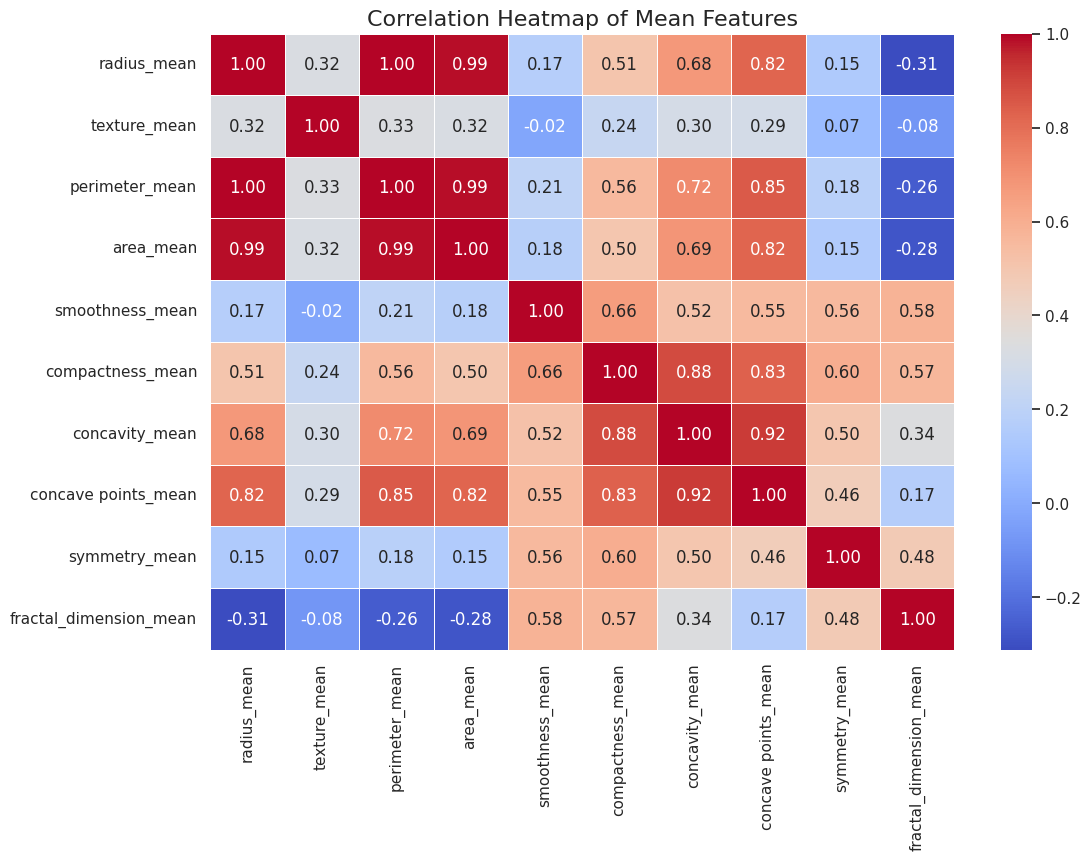

In [18]:
plt.figure(figsize=(12, 8))
selected_features = df_clean.columns[:10]
correlation_matrix = df_clean[selected_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Mean Features", fontsize=16)
plt.show()

In [19]:
X = df_clean.drop('target', axis=1)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [20]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

param_distributions = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 200, 300]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=25,          # Number of parameter settings to sample
    scoring='roc_auc',  # Optimizing for ROC-AUC
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Hyperparameter Tuning...")
random_search.fit(X_train_scaled, y_train)

print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f"\nBest Cross-Validation ROC-AUC Score: {random_search.best_score_:.4f}")

best_xgb_model = random_search.best_estimator_

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Parameters Found:
{'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best Cross-Validation ROC-AUC Score: 0.9950


--- Model Evaluation on Test Set ---
Accuracy: 0.9561
ROC-AUC Score: 0.9927

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



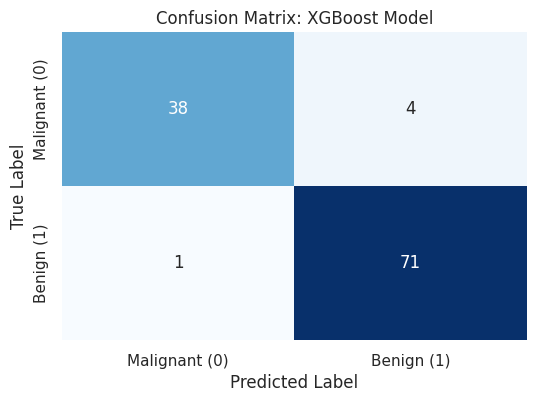

In [21]:
y_pred = best_xgb_model.predict(X_test_scaled)
y_pred_proba = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("--- Model Evaluation on Test Set ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: XGBoost Model')
plt.show()

In [22]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True)
    }

    optuna_xgb = xgb.XGBClassifier(**param)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        optuna_xgb,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

print("Starting Optuna Optimization Study...")

study = optuna.create_study(direction='maximize', study_name="XGBoost_Cancer_Optimization")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n--- Optuna Tuning Results ---")
print(f"Best ROC-AUC Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

best_optuna_params = study.best_params
best_optuna_params['objective'] = 'binary:logistic'
best_optuna_params['eval_metric'] = 'logloss'
best_optuna_params['random_state'] = 42

final_optuna_model = xgb.XGBClassifier(**best_optuna_params)
final_optuna_model.fit(X_train_scaled, y_train)

y_pred = final_optuna_model.predict(X_test_scaled)
y_pred_proba = final_optuna_model.predict_proba(X_test_scaled)[:, 1]

print("\nFinal optimized model successfully trained!")

Starting Optuna Optimization Study...


  0%|          | 0/50 [00:00<?, ?it/s]


--- Optuna Tuning Results ---
Best ROC-AUC Score: 0.9953
Best Hyperparameters:
  max_depth: 5
  min_child_weight: 1
  learning_rate: 0.2072390239565987
  n_estimators: 197
  subsample: 0.679919122587166
  colsample_bytree: 0.956203992969299
  alpha: 0.00021977350677117736
  lambda: 2.146856060132081e-06

Final optimized model successfully trained!


In [23]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("--- Final Model Evaluation on Test Set ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

--- Final Model Evaluation on Test Set ---
Accuracy: 0.9649
ROC-AUC Score: 0.9947



In [24]:
import shap

shap.initjs()

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

explainer = shap.TreeExplainer(best_xgb_model)

shap_values = explainer.shap_values(X_test_scaled_df)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


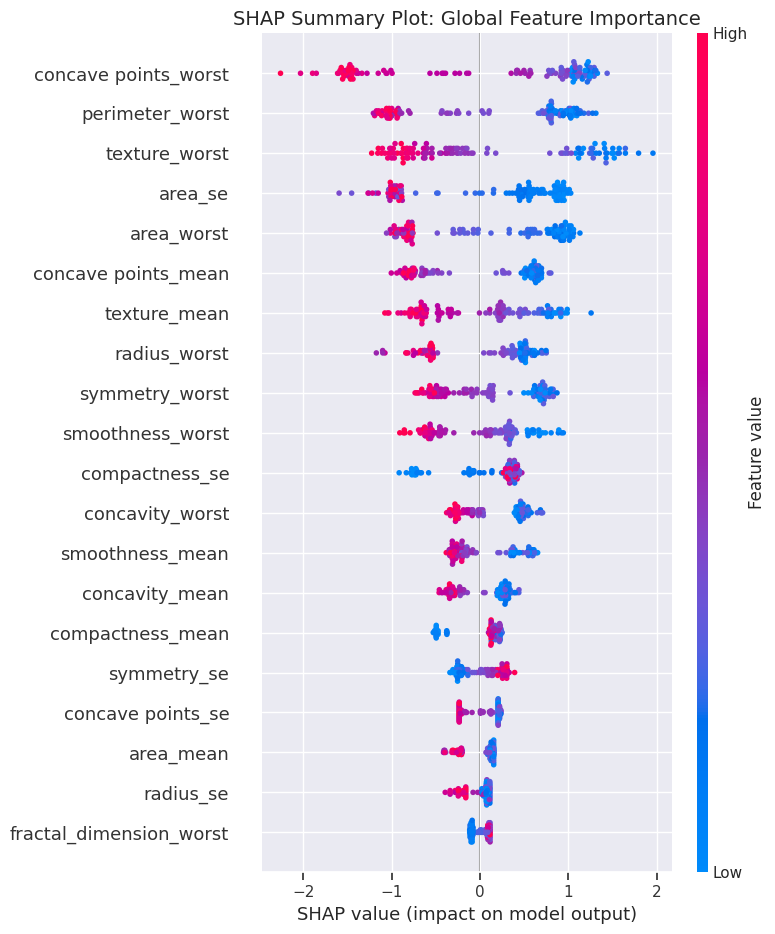

In [25]:
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: Global Feature Importance", fontsize=14)

shap.summary_plot(shap_values, X_test_scaled_df, show=False)

plt.tight_layout()
plt.show()

Explaining prediction for Patient Index: 0
Actual Diagnosis: Malignant (0)
Model Predicted Probability of being Benign: 0.0006


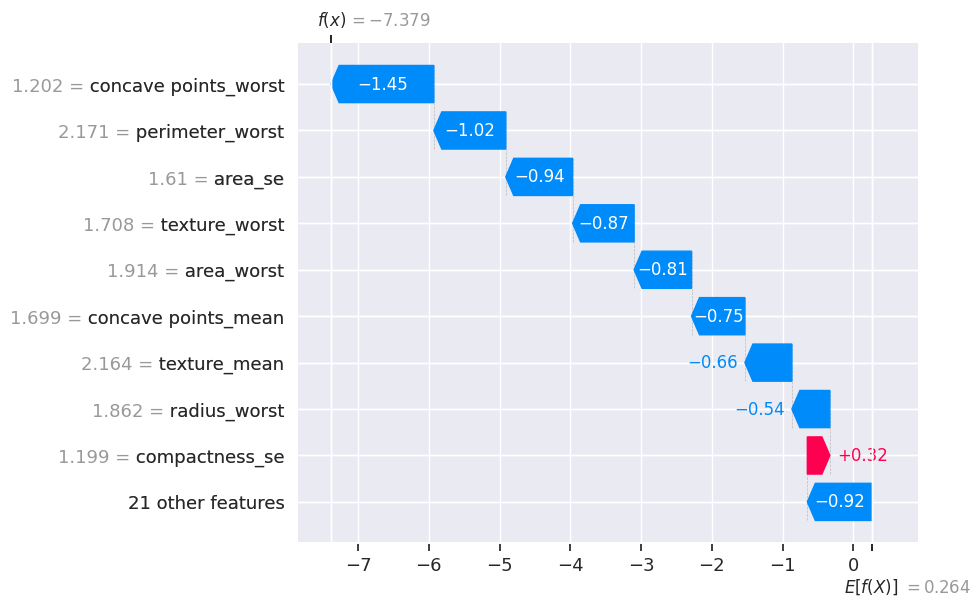

In [26]:
patient_index = 0

print(f"Explaining prediction for Patient Index: {patient_index}")
print(f"Actual Diagnosis: {'Benign (1)' if y_test.iloc[patient_index] == 1 else 'Malignant (0)'}")

patient_data = X_test_scaled_df.iloc[[patient_index]]
predicted_prob = best_xgb_model.predict_proba(patient_data)[0][1]
print(f"Model Predicted Probability of being Benign: {predicted_prob:.4f}")

shap_explanation = explainer(X_test_scaled_df)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation[patient_index])
plt.show()